# PyTorch 与神经网络模型实践

## 1. PyTorch 基础

### 1.1 张量运算

**请使用 PyTorch 内置函数完成，避免显式循环。**

1. 创建一个形状为 (6, 5) 的随机整数张量 `A`，取值范围为 {0, 1, ..., 10}。打印出该张量；
2. 将 `A` 的每一行减去该行的均值（行中心化），得到张量 `A_centered`，使用广播实现。打印出该张量；
3. 打印出 `A_centered` 的行和向量以及列和向量。

In [1]:
import torch

A = torch.randint(0, 11, (6, 5))
print("A:")
print(A)

row_mean = A.float().mean(dim=1, keepdim=True)
A_centered = A - row_mean

print("A_centered:")
print(A_centered)

print("行向量:")
print(A_centered.sum(dim=1))

print("列向量:")
print(A_centered.sum(dim=0))

A:
tensor([[ 7,  9, 10,  8, 10],
        [10,  0,  9,  2,  2],
        [ 0,  0,  3,  1,  0],
        [ 3,  0,  0,  8,  5],
        [ 5,  3,  7,  0,  0],
        [ 9, 10,  9, 10,  8]])
A_centered:
tensor([[-1.8000,  0.2000,  1.2000, -0.8000,  1.2000],
        [ 5.4000, -4.6000,  4.4000, -2.6000, -2.6000],
        [-0.8000, -0.8000,  2.2000,  0.2000, -0.8000],
        [-0.2000, -3.2000, -3.2000,  4.8000,  1.8000],
        [ 2.0000,  0.0000,  4.0000, -3.0000, -3.0000],
        [-0.2000,  0.8000, -0.2000,  0.8000, -1.2000]])
行向量:
tensor([-9.5367e-07,  4.7684e-07, -5.9605e-08,  0.0000e+00,  0.0000e+00,
         9.5367e-07])
列向量:
tensor([ 4.4000, -7.6000,  8.4000, -0.6000, -4.6000])


以下每一步都需打印出操作的结果。

1. 创建一个形状为 (8, 8) 的随机正态分布张量 `X`（均值为 0.5，方差为2）；
2. 提取 `X` 中所有大于1.5的元素，构成一维张量；
3. 将 `X` 中绝对值小于0.5的元素替换为0，结果保存为张量 `X_masked`；
4. 取出 `X` 的第2行、第4列的元素；
5. 取出 `X` 的第3-6行、第2-5列构成的子矩阵。

In [2]:
import torch

X = torch.normal(mean=0.5, std=2**0.5, size=(8, 8))
print("X:")
print(X)

x_gt_15 = X[X > 1.5]
print("大于1.5的元素:")
print(x_gt_15)

X_masked = X.clone()
X_masked[X_masked.abs() < 0.5] = 0
print("X_masked:")
print(X_masked)

print("第2行第4列元素:")
print(X[1, 3])

sub_X = X[2:6, 1:5]
print("第3-6行、第2-5列子矩阵:")
print(sub_X)

X:
tensor([[ 1.9164,  1.9853,  0.1937,  2.1814, -0.3252, -0.1160, -1.9403, -0.7656],
        [-0.7319,  0.6810,  1.3119, -3.3548,  2.7123, -0.1774, -1.6905,  0.3221],
        [ 3.9726,  0.3507, -0.1668,  0.8575,  1.5865,  1.3943,  0.8012,  0.8557],
        [-1.8483,  0.7446,  2.0180,  2.1724,  0.7628,  1.8959, -1.1523, -2.3723],
        [ 1.8100, -0.9909, -0.1674, -3.1395,  1.9955, -0.1274,  1.8058,  2.1152],
        [ 1.5429, -0.5444,  0.3573,  0.1455,  1.9969, -4.2458,  2.8931,  1.2461],
        [-0.2780,  1.4818, -1.7701,  0.5374,  1.8783,  3.2287,  2.6234,  1.7166],
        [ 0.5198,  0.3091, -0.1038,  0.6502, -0.4501, -0.7195, -0.1816, -1.3712]])
大于1.5的元素:
tensor([1.9164, 1.9853, 2.1814, 2.7123, 3.9726, 1.5865, 2.0180, 2.1724, 1.8959,
        1.8100, 1.9955, 1.8058, 2.1152, 1.5429, 1.9969, 2.8931, 1.8783, 3.2287,
        2.6234, 1.7166])
X_masked:
tensor([[ 1.9164,  1.9853,  0.0000,  2.1814,  0.0000,  0.0000, -1.9403, -0.7656],
        [-0.7319,  0.6810,  1.3119, -3.3548,  2.7123,

### 1.2 常见函数与自动微分

多分类问题的数据通常包括数据阵 $X$ 和标签向量 $l$，其中标签为整数。在计算损失函数时，我们需要先将 $l$ 转换成多项分布的0-1数据，即所谓 One-hot 编码。运行并观察下面的代码。

In [3]:
import numpy as np
import torch
import torch.nn as nn

np.random.seed(123456)
torch.manual_seed(123456)

n = 200  # 样本量
p = 10   # 变量数
k = 4    # 类别数
x = torch.randn(n, p)
l = torch.tensor(np.random.choice(range(4), size=n, replace=True), dtype=int)
print(l[:20])

y = torch.nn.functional.one_hot(l)
print(y.shape)
print(y[:10])

tensor([1, 2, 2, 1, 0, 3, 3, 3, 3, 0, 3, 0, 0, 2, 2, 0, 3, 0, 3, 3])
torch.Size([200, 4])
tensor([[0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [1, 0, 0, 0]])


请创建矩阵 `W`，大小为 $k \times p$，用 N(0, 2) 填充其取值。

In [4]:
W = torch.normal(mean=0, std=2, size=(k, p))

# 检查 W 的形状，方便 debug
assert W.shape == (k, p), "W 形状有误"

接下来计算对 $Y$ 的概率预测值，其中每个 $Y_i$ 观测对应一个等长的概率向量 $p_i$，而 $p_i=\mathrm{Softmax}(Wx_i)$。首先计算 $Wx_i$，其中 $x_i$ 是第 $i$ 个观测。由于 $X$ 是把 $x_i$ 按行组合，因此矩阵形式表达为 $U=XW'$，其中 $U$ 的第 $i$ 行即为 $Wx_i$。

In [5]:
U = x @ W.T

# 检查 U 的形状，方便 debug
assert U.shape == (n, k), "U 形状有误"

我们先测试一下 $\mathrm{Softmax}(Wx_{100})$ 的结果，观察其元素和是否为1。代码中的 `dim=0` 意思是对第一个下标方向计算 Softmax，由于 `U[99]` 是一个向量，因此第一个下标方向就是该向量本身。

In [8]:
torch.softmax(U[99], dim=0)

tensor([0.0897, 0.0053, 0.8493, 0.0556])

而为了对 $U$ 的每一行都计算 Softmax，我们可以直接对整个 `U` 矩阵用 `torch.softmax`，其中 `dim` 需指定为1，意思是对第二个下标方向求 Softmax，即对 $U$ 的每一行。原理类似于按坐标轴汇总。请完成该计算，得到矩阵 $P$，其中 $P$ 的第 $i$ 行即为 $p_i$。

In [9]:
P = torch.softmax(U, dim=1)

# 检查 P 的形状，方便 debug
assert P.shape == (n, k), "P 形状有误"

根据 `y` 和 `P` 两个矩阵，即可根据公式得到对数似然函数值。总结上述步骤，编写损失函数 `loss_fn_softmax(w, x, y)`，返回**负**对数似然值。

In [12]:
def loss_fn_softmax(W, x, y):
    U = x @ W.T
    P = torch.softmax(U, dim=1)
    loss = -(y.float() * torch.log(P)).sum(dim=1).mean()
    return loss

Pytorch 中也提供了 CrossEntropyLoss 损失函数，参见[其文档](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)。其用法是先建立一个损失函数对象，然后将 $U$ 和 $l$ 作为参数传入（注意 $U$ 是经过 Softmax **之前**的矩阵，$l$ 是**原始**的标签）。请利用这种方法计算损失函数值，并与你自己的函数结果进行对比。

In [ ]:
ce_softmax = nn.CrossEntropyLoss()
loss1 = ce_softmax(U, l)

loss2 = loss_fn_softmax(W, x, y)

print(loss1)
print(loss2)

tensor(6.1617)
0.0


【可以在此处添加必要的说明文字】

利用 PyTorch 的自动微分功能，计算上述损失函数在 $W=O$ 处的梯度，其中 $O$ 是一个元素全为0的矩阵。

In [16]:
import numpy as np
import torch
import torch.nn as nn

np.random.seed(123456)
torch.manual_seed(123456)

n = 200
p = 10
k = 4

x = torch.randn(n, p)
l = torch.tensor(np.random.choice(range(4), size=n, replace=True), dtype=torch.long)
y = torch.nn.functional.one_hot(l)

W = torch.normal(mean=0, std=2, size=(k, p))
U = x @ W.T
P = torch.softmax(U, dim=1)

def loss_fn_softmax(W, x, y):
    U = x @ W.T
    P = torch.softmax(U, dim=1)
    loss = -(y.float() * torch.log(P)).sum(dim=1).mean()
    return loss

W0 = torch.zeros((k, p), requires_grad=True)

loss = loss_fn_softmax(W0, x, y)
loss.backward()

print("loss:")
print(loss)

print("W的梯度:")
print(W0.grad)

print("梯度形状:")
print(W0.grad.shape)

loss:
tensor(1.3863, grad_fn=<NegBackward0>)
W的梯度:
tensor([[-0.0198,  0.0474,  0.0067, -0.0427, -0.0012, -0.0092,  0.0167,  0.0030,
          0.0800, -0.0152],
        [ 0.0250, -0.0273, -0.0283,  0.0377,  0.0333, -0.0031,  0.0130,  0.0072,
         -0.0125,  0.0173],
        [-0.0236, -0.0355,  0.0060,  0.0342, -0.0175,  0.0324, -0.0054,  0.0260,
          0.0312, -0.0129],
        [ 0.0183,  0.0154,  0.0155, -0.0292, -0.0146, -0.0201, -0.0243, -0.0363,
         -0.0988,  0.0108]])
梯度形状:
torch.Size([4, 10])


## 2. 前馈神经网络

### 2.1 线性模型

利用模块化编程（参考课件 `lec6-module.ipynb` 中的实现），在如下模拟数据上构建一个 Logistic 回归模型（包含截距项），并利用自动微分和优化器求解回归系数。要求使用 PyTorch 中的 `nn.Linear` 模块完成模型构建。

In [17]:
import numpy as np

def gen_data(n_obs=1000, radius=1.0, eye_oversample_ratio=0.0):
    factor = 1.5
    n_candidates = int(n_obs * factor)
    points = np.random.uniform(-radius, radius, size=(n_candidates, 2))

    r_sq = np.sum(points**2, axis=1)
    inside = (r_sq <= radius**2)
    points = points[inside]

    while len(points) < n_obs:
        extra = np.random.uniform(-radius, radius, size=(n_obs, 2))
        inside_extra = (np.sum(extra**2, axis=1) <= radius**2)
        extra = extra[inside_extra]
        points = np.vstack([points, extra])
    points = points[:n_obs]

    x1, x2 = points[:, 0], points[:, 1]
    half_r = radius / 2.0
    eye_r = radius / 5.0

    upper_semi = (x1 > 0) & ((x1**2 + (x2 - half_r)**2) <= half_r**2)
    lower_semi = (x1 < 0) & ((x1**2 + (x2 + half_r)**2) <= half_r**2)

    yang_eye = (x1**2 + (x2 - half_r)**2) <= eye_r**2
    yin_eye = (x1**2 + (x2 + half_r)**2) <= eye_r**2

    labels = np.full(len(points), -1, dtype=int)
    labels[upper_semi] = 0
    labels[yang_eye] = 1
    labels[lower_semi] = 1
    labels[yin_eye] = 0

    rest = (labels == -1)
    labels[rest & (x1 >= 0)] = 1
    labels[rest & (x1 < 0)] = 0

    if eye_oversample_ratio > 0:
        n_extra = int(n_obs * eye_oversample_ratio)

        def sample_disk(center, radius_disk, n):
            pts = np.random.uniform(-radius_disk, radius_disk, size=(int(n * 1.5), 2))
            inside_d = np.sum(pts**2, axis=1) <= radius_disk**2
            pts = pts[inside_d][:n]
            while len(pts) < n:
                extra_pts = np.random.uniform(-radius_disk, radius_disk, size=(n, 2))
                in_extra = np.sum(extra_pts**2, axis=1) <= radius_disk**2
                extra_pts = extra_pts[in_extra]
                pts = np.vstack([pts, extra_pts])[:n]
            return pts + np.array(center)

        extra_yang_pts = sample_disk(center=(0, half_r), radius_disk=eye_r, n=n_extra)
        extra_yang_labels = np.ones(n_extra, dtype=int)

        extra_yin_pts = sample_disk(center=(0, -half_r), radius_disk=eye_r, n=n_extra)
        extra_yin_labels = np.zeros(n_extra, dtype=int)

        points = np.vstack([points, extra_yang_pts, extra_yin_pts])
        labels = np.concatenate([labels, extra_yang_labels, extra_yin_labels])

    return points, labels

np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)
print(x[:5])
print(y[:5])

[[-4.79047988  7.94473049]
 [-2.46500568 -3.27556511]
 [-0.97247059  6.80510167]
 [-7.53795711  0.86052404]
 [-2.5397555  -1.04006351]]
[0 1 0 0 1]


数据散点图：

<Axes: xlabel='x1', ylabel='x2'>

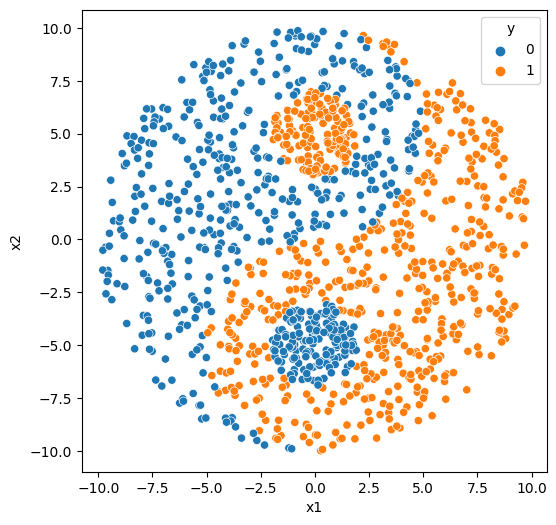

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dat = pd.DataFrame(x, columns=["x1", "x2"])
dat["y"] = y
plt.figure(figsize=(6, 6))
sns.scatterplot(data=dat, x="x1", y="x2", hue="y")

请在下方完成训练代码：

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

x_train = torch.tensor(x, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32).view(-1, 1)

model = nn.Linear(2, 1)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

for epoch in range(1000):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(epoch, loss.item())

0 2.226113796234131
200 0.500649094581604
400 0.500649094581604
600 0.500649094581604
800 0.500649094581604


完成模型训练后，利用得到的模型对如下测试集数据进行预测（概率 >0.5 判为1，反之判为0），计算分类的正确率。

In [19]:
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

In [20]:
x_test = torch.tensor(xtest, dtype=torch.float32)
y_test = torch.tensor(ytest, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    logits = model(x_test)
    prob = torch.sigmoid(logits)
    pred = (prob > 0.5).float()

acc = (pred == y_test).float().mean()

print("分类准确率：")
print(acc.item())

分类准确率：
0.6666666865348816


### 2.2 前馈神经网络

修改上面的线性模型，将其变为一个两层的前馈神经网络，隐藏神经元数量为32，使用 ReLU 激活函数。然后重新训练模型（可尝试使用不同的学习率和迭代次数），记录每次迭代的损失函数值并绘制损失函数值随迭代次数的曲线。最后对测试集进行预测，计算分类的正确率（目标是 >90%）。

0 0.6482036113739014
200 0.25353485345840454
400 0.14807747304439545
600 0.11751732975244522
800 0.10121709108352661
1000 0.08176062256097794
1200 0.06530338525772095
1400 0.05491301044821739
1600 0.04761435091495514
1800 0.04099858179688454


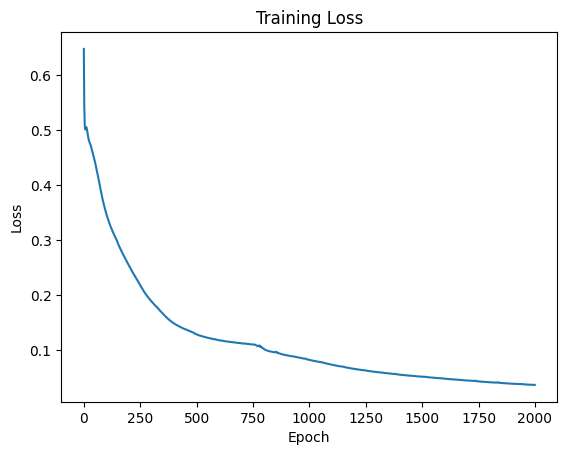

测试集准确率： 0.9666666388511658


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x_train = torch.tensor(x, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32).view(-1, 1)

x_test = torch.tensor(xtest, dtype=torch.float32)
y_test = torch.tensor(ytest, dtype=torch.float32).view(-1, 1)

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_list = []

for epoch in range(2000):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()
    
    loss_list.append(loss.item())
    
    if epoch % 200 == 0:
        print(epoch, loss.item())

plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

with torch.no_grad():
    pred = (torch.sigmoid(model(x_test)) > 0.5).float()
    acc = (pred == y_test).float().mean()

print("测试集准确率：", acc.item())

### 2.3 Muon 优化器

请重新对上述前馈神经网络进行初始化和训练，但使用 Muon 优化器。**注意：Muon 只能对矩阵型参数进行优化，把向量型的参数传递给 Muon 会报错。**

请使用如下思路解决：构建两个优化器，Adam 和 Muon，将模型的参数分成两个列表，矩阵类的传递给 Muon，其他类的传递给 Adam，然后在训练循环中分别调用两个优化器的 `zero_grad()` 和 `step()` 函数。

请记录下这种方式下每次迭代的损失函数值，并与上一节中的曲线绘制在同一张图中进行对比。

0 0.7425663471221924
200 0.3338974118232727
400 0.21536456048488617
600 0.14284168183803558
800 0.10733047127723694
1000 0.09041326493024826
1200 0.0815059170126915
1400 0.0748266950249672
1600 0.0711197704076767
1800 0.061811912804841995


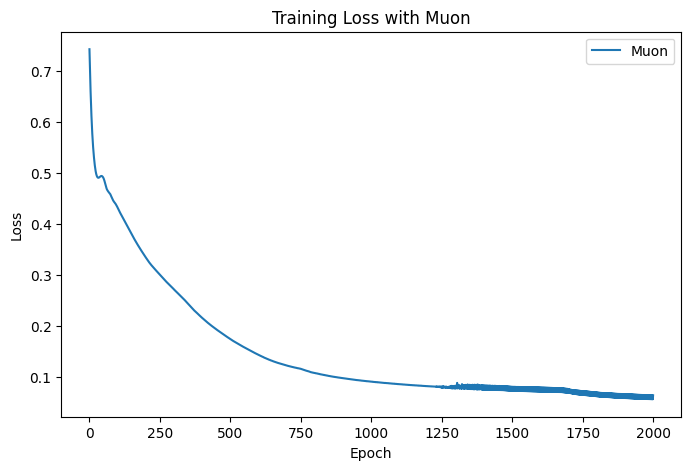

Muon测试集准确率：
0.9624999761581421


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 如果前面没运行过数据转换，先运行这几行
x_train = torch.tensor(x, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32).view(-1, 1)

x_test = torch.tensor(xtest, dtype=torch.float32)
y_test = torch.tensor(ytest, dtype=torch.float32).view(-1, 1)


# 简化版 Muon，避免 GitHub 安装失败
class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.01, momentum=0.95):
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            momentum = group["momentum"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                g = p.grad

                state = self.state[p]
                if len(state) == 0:
                    state["buf"] = torch.zeros_like(p)

                buf = state["buf"]
                buf.mul_(momentum).add_(g)

                if p.ndim >= 2:
                    u, s, v = torch.linalg.svd(buf, full_matrices=False)
                    update = u @ v
                else:
                    update = buf

                p.add_(update, alpha=-lr)


# 建立模型
model_muon = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn = nn.BCEWithLogitsLoss()

# 参数分类：矩阵参数给 Muon，向量参数给 Adam
matrix_params = []
other_params = []

for name, param in model_muon.named_parameters():
    if param.ndim >= 2:
        matrix_params.append(param)
    else:
        other_params.append(param)

optimizer_muon = Muon(matrix_params, lr=0.01)
optimizer_adam = optim.Adam(other_params, lr=0.01)

loss_list_muon = []

# 训练
for epoch in range(2000):
    optimizer_muon.zero_grad()
    optimizer_adam.zero_grad()

    logits = model_muon(x_train)
    loss = loss_fn(logits, y_train)

    loss.backward()

    optimizer_muon.step()
    optimizer_adam.step()

    loss_list_muon.append(loss.item())

    if epoch % 200 == 0:
        print(epoch, loss.item())


# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(loss_list_muon, label="Muon")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss with Muon")
plt.legend()
plt.show()


# 测试集准确率
with torch.no_grad():
    logits_test = model_muon(x_test)
    prob_test = torch.sigmoid(logits_test)
    pred_test = (prob_test > 0.5).float()
    acc = (pred_test == y_test).float().mean()

print("Muon测试集准确率：")
print(acc.item())

## 3. 预训练模型实战

请学习语音识别模型 Whisper 的使用方法（访问 [https://hf-mirror.com/openai/whisper-small](https://hf-mirror.com/openai/whisper-small) 或 [https://huggingface.co/openai/whisper-small](https://huggingface.co/openai/whisper-small)），完成以下任务：

1. 准备一段文字（内容任意，朗读出来大约10秒钟），填写在下方的文本框里。
2. 朗读这段文字，利用录音软件录制一段10秒左右的音频，保存为 `.wav` 格式。
3. 根据网站上的文档学习使用 Whisper 预训练模型，将预训练模型下载到本地，并识别你录制的音频，将其转为文字，打印出来。
4. 配备有 Nvidia GPU 的同学可以尝试参数量更大的 Whisper-Large 模型（访问 [https://hf-mirror.com/openai/whisper-large-v3](https://hf-mirror.com/openai/whisper-large-v3) 或 [https://huggingface.co/openai/whisper-large-v3](https://huggingface.co/openai/whisper-large-v3)），在 CUDA 模式下运行模型。

真实文字内容：现在是2026年5月25日七点二十六分

语音文件的文件名：国通路131号.wav

In [25]:
!pip install openai-whisper
!pip install ffmpeg-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 757.5 kB/s  0:00:01a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 237.0 kB/s  0:00:11m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 394.3 kB/s  0:01:29m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 678.4 kB/s  0:00:02eta 0:00:01
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=989c488468008e101d4477a14997c6a8c88b132937189e2aa5394dd714ed5653
  Stored in directory: /Users/zzzzhang/Library/Caches/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [openai-whisper]m [numba]te]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ffmpeg-python]


In [27]:
import os
import glob

# 删除损坏的 whisper 模型缓存
for f in glob.glob(os.path.expanduser("~/.cache/whisper/*")):
    os.remove(f)

print("已清理缓存")

已清理缓存


In [29]:
!conda install -c conda-forge ffmpeg -y

Unexpected error writing token file:
  path: /Users/zzzzhang/.conda/aau_token_host
  exception: write() argument must be str, not None
Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1032)')': /pkgs/main/terms.json

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/anaconda3/envs/xigua

  added / updated specs:
    - ffmpeg


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |     

In [1]:
import whisper

model = whisper.load_model("base")
result = model.transcribe("国通路131号.wav", language="zh")

print("Whisper识别结果：")
print(result["text"])

/opt/anaconda3/envs/xigua/lib/python3.12/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Whisper识别结果：
現在是2026年5月25日週一7.26分
